In [1]:
import os
import glob
import json
import re
import base64
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

%matplotlib inline

BASE_DIR = os.path.abspath('..')
DATA_DIR = os.path.join(BASE_DIR, 'data')
REC_DIR  = os.path.join(DATA_DIR, 'receipts_raw')
OUT_DIR  = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUT_DIR, exist_ok=True)

rec_paths = glob.glob(os.path.join(REC_DIR, '*'))
print("Total receipts:", len(rec_paths))

Total receipts: 101


In [2]:
def show_image(title, img, cmap=None, size=(6, 6)):
    plt.figure(figsize=size)
    if cmap is None:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()

def get_skew_angle(img):
    edges = cv2.Canny(img, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180,
                            threshold=100, minLineLength=100, maxLineGap=10)
    if lines is None:
        return 0.0
    angles = [np.degrees(np.arctan2(l[0][3]-l[0][1], l[0][2]-l[0][0])) for l in lines]
    return np.median(angles)

def deskew(img):
    angle = get_skew_angle(img)
    if abs(angle) < 1.0:
        return img
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)

def preprocess_receipt(img_path, target_width=800):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    gray = cv2.resize(gray, (target_width, int(h * target_width / w)))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    denoised = cv2.GaussianBlur(enhanced, (3, 3), 0)
    thresh = cv2.adaptiveThreshold(
        denoised, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )
    return deskew(thresh)

In [3]:
OCR_SPACE_API_KEY = "K83710360488957"

def run_ocr_space(image_path, api_key=OCR_SPACE_API_KEY):
    with open(image_path, 'rb') as f:
        response = requests.post(
            "https://api.ocr.space/parse/image",
            files={"file": f},
            data={
                "apikey": api_key,
                "language": "eng",
                "isOverlayRequired": False,
                "OCREngine": 2
            }
        )
    return response.json()

def extract_text_from_ocr_space(result):
    parsed = result.get("ParsedResults", [])
    return "\n".join([r.get("ParsedText", "") for r in parsed]).strip()

def get_ocr_text(img_path):
    """
    READ from saved txt if it exists — skip OCR API call.
    Only call OCR API if txt not found.
    """
    filename = os.path.basename(img_path)
    txt_path = os.path.join(OUT_DIR, filename.replace('.jpg', '_ocr.txt'))

    if os.path.exists(txt_path):
        print(f" Using saved OCR txt: {os.path.basename(txt_path)}")
        with open(txt_path, 'r', encoding='utf-8') as f:
            return f.read().strip()

    print(f"  Running OCR API for: {filename}")
    preprocessed = preprocess_receipt(img_path)
    temp_path = os.path.join(OUT_DIR, filename.replace('.jpg', '_prep.png'))
    cv2.imwrite(temp_path, preprocessed)

    ocr_result = run_ocr_space(temp_path)
    ocr_text = extract_text_from_ocr_space(ocr_result)

    with open(txt_path, 'w', encoding='utf-8') as f:
        f.write(ocr_text)

    return ocr_text

In [ ]:
from groq import Groq
import json
import time

GROQ_API_KEY = ""
groq_client = Groq(api_key=GROQ_API_KEY)

def extract_fields_with_groq(ocr_text):
    prompt = f"""You are a receipt data extraction assistant.
Given raw OCR text from a scanned receipt, extract these fields and return ONLY a valid JSON object. Use null for missing fields. No explanation, no markdown.

Fields:
- merchant: store or business name ONLY (not a person name, not TAX INVOICE, not CASH CUSTOMER, not CREDIT NOTE)
- date: YYYY-MM-DD
- time: HH:MM:SS
- currency: always ISO code — MYR for RM, USD, LKR, SGD etc.
- subtotal: number only
- tax: GST/tax as number only
- total: final total paid as number only
- payment_method: CASH, VISA, MASTERCARD etc.
- category: classify the receipt into ONE of these: Food & Beverage, Grocery, Transport, Retail, Hardware & Tools, Electronics, Fuel, Parking, Healthcare, Other
- items: list of objects each with: name, qty, unit_price, total_price

OCR TEXT:
{ocr_text}

JSON only:"""

    response = groq_client.chat.completions.create(
        model="meta-llama/llama-4-scout-17b-16e-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=1000,
        response_format={"type": "json_object"}
    )

    raw = response.choices[0].message.content.strip()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        print(" JSON parse error:", raw[:200])
        return {}

In [5]:
CURRENCY_TO_USD = {
    "MYR": 0.24,   # Malaysian Ringgit
    "RM":  0.24,   # Some receipts print RM instead of MYR
    "SGD": 0.74,   # Singapore Dollar
    "LKR": 0.0055, # Sri Lankan Rupee
    "USD": 1.0,
    "GBP": 1.27,
    "EUR": 1.08,
    "INR": 0.012,
}

def convert_to_usd(amount, currency):
    if amount is None:
        return None
    try:
        amount = float(amount)
        rate = CURRENCY_TO_USD.get(str(currency).upper().strip(), None)
        if rate is None:
            return None
        return round(amount * rate, 4)
    except (ValueError, TypeError):
        return None

In [ ]:
def process_receipt_full_pipeline(img_path):
    """
    Pipeline:
    1. OpenCV preprocessing (CV WORK)
    2. Read saved OCR txt OR call OCR.Space if not exists
    3. Groq/Llama parses fields from OCR text (AI for understanding only)
    4. Convert all amounts to USD
    """
    filename = os.path.basename(img_path)

    # Step 1 + 2: Get OCR text (from saved file or API)
    ocr_text = get_ocr_text(img_path)

    # Step 3: Groq field parsing from OCR text
    if ocr_text.strip():
        fields = extract_fields_with_groq(ocr_text)
    else:
        print(f" Empty OCR text for {filename}")
        fields = {}

    currency = fields.get("currency")
    subtotal = fields.get("subtotal")
    tax      = fields.get("tax")
    total    = fields.get("total")

    # Step 4: Convert to USD
    return {
    "file":             filename,
    "merchant":         fields.get("merchant"),
    "date":             fields.get("date"),
    "time":             fields.get("time"),
    "currency":         currency,
    "category":         fields.get("category"),
    "subtotal_orig":    subtotal,
    "tax_orig":         tax,
    "total_orig":       total,
    "subtotal_usd":     convert_to_usd(subtotal, currency),
    "tax_usd":          convert_to_usd(tax, currency),
    "total_usd":        convert_to_usd(total, currency),
    "payment_method":   fields.get("payment_method"),
    "items":            json.dumps(fields.get("items", [])),
    "ocr_text_preview": ocr_text[:200]
}

In [7]:
results = []

for i, img_path in enumerate(rec_paths):
    print(f"Processing ({i+1}/{len(rec_paths)}): {os.path.basename(img_path)}")
    try:
        result = process_receipt_full_pipeline(img_path)
        results.append(result)
        time.sleep(2)
    except Exception as e:
        print(f" Error: {e}")
        results.append({"file": os.path.basename(img_path), "error": str(e)})

df = pd.DataFrame(results)
df.to_csv(os.path.join(OUT_DIR, "ocr_batch_results.csv"), index=False)
print(f" Done! Processed {len(df)} receipts")

Processing (1/101): 000.jpg
 Using saved OCR txt: 000_ocr.txt
Processing (2/101): 001.jpg
 Using saved OCR txt: 001_ocr.txt
Processing (3/101): 002.jpg
 Using saved OCR txt: 002_ocr.txt
Processing (4/101): 003.jpg
 Using saved OCR txt: 003_ocr.txt
Processing (5/101): 004.jpg
 Using saved OCR txt: 004_ocr.txt
Processing (6/101): 005.jpg
 Using saved OCR txt: 005_ocr.txt
Processing (7/101): 006.jpg
 Using saved OCR txt: 006_ocr.txt
Processing (8/101): 007.jpg
 Using saved OCR txt: 007_ocr.txt
Processing (9/101): 008.jpg
 Using saved OCR txt: 008_ocr.txt
Processing (10/101): 009.jpg
 Using saved OCR txt: 009_ocr.txt
 Empty OCR text for 009.jpg
Processing (11/101): 010.jpg
  Running OCR API for: 010.jpg
Processing (12/101): 011.jpg
  Running OCR API for: 011.jpg
Processing (13/101): 012.jpg
  Running OCR API for: 012.jpg
 Empty OCR text for 012.jpg
Processing (14/101): 013.jpg
  Running OCR API for: 013.jpg
Processing (15/101): 014.jpg
  Running OCR API for: 014.jpg
Processing (16/101): 01

KeyboardInterrupt: 

In [ ]:
df = pd.DataFrame(results)

# define df_summary here
df_summary = df.drop(columns=["items", "ocr_text_preview"], errors="ignore")

print("\nMissing values:")
print(df_summary.isna().sum())

print("\nCurrency distribution:")
print(df_summary["currency"].value_counts())

print("\nPayment methods:")
print(df_summary["payment_method"].value_counts())

print("\nUSD total range:")
print(df_summary["total_usd"].describe())


Missing values:
file              0
merchant          1
date              2
time              2
currency          1
subtotal_orig     2
tax_orig          5
total_orig        2
subtotal_usd      2
tax_usd           5
total_usd         2
payment_method    3
dtype: int64

Currency distribution:
currency
MYR    9
Name: count, dtype: int64

Payment methods:
payment_method
CASH    4
VISA    2
null    1
Name: count, dtype: int64

USD total range:
count      8.000000
mean      31.203300
std       34.584741
min        1.596000
25%        4.617000
50%       24.883200
75%       42.180000
max      103.716000
Name: total_usd, dtype: float64


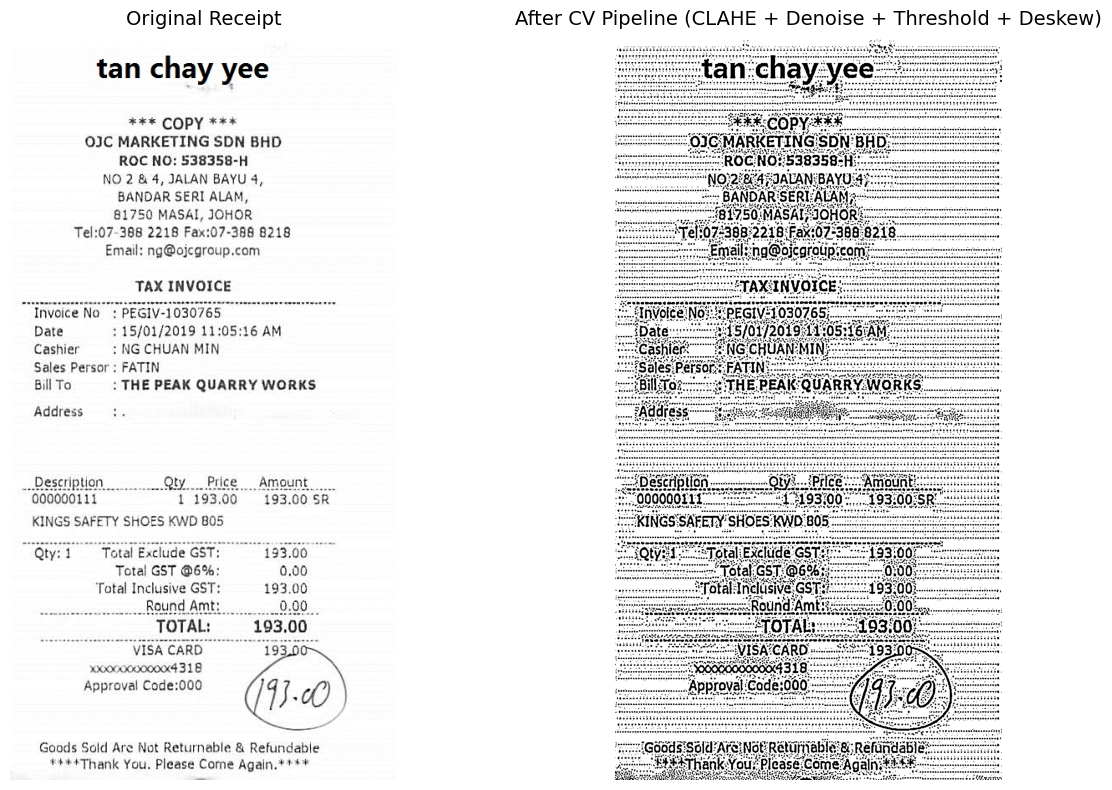

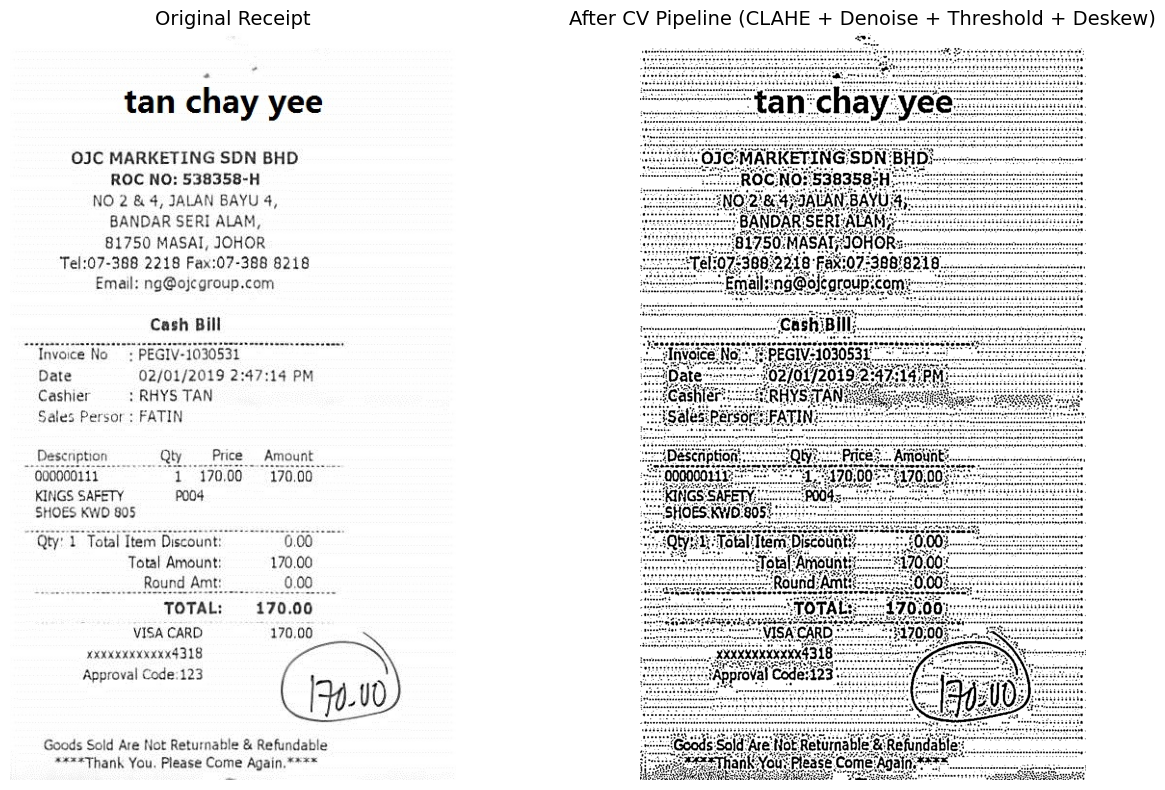

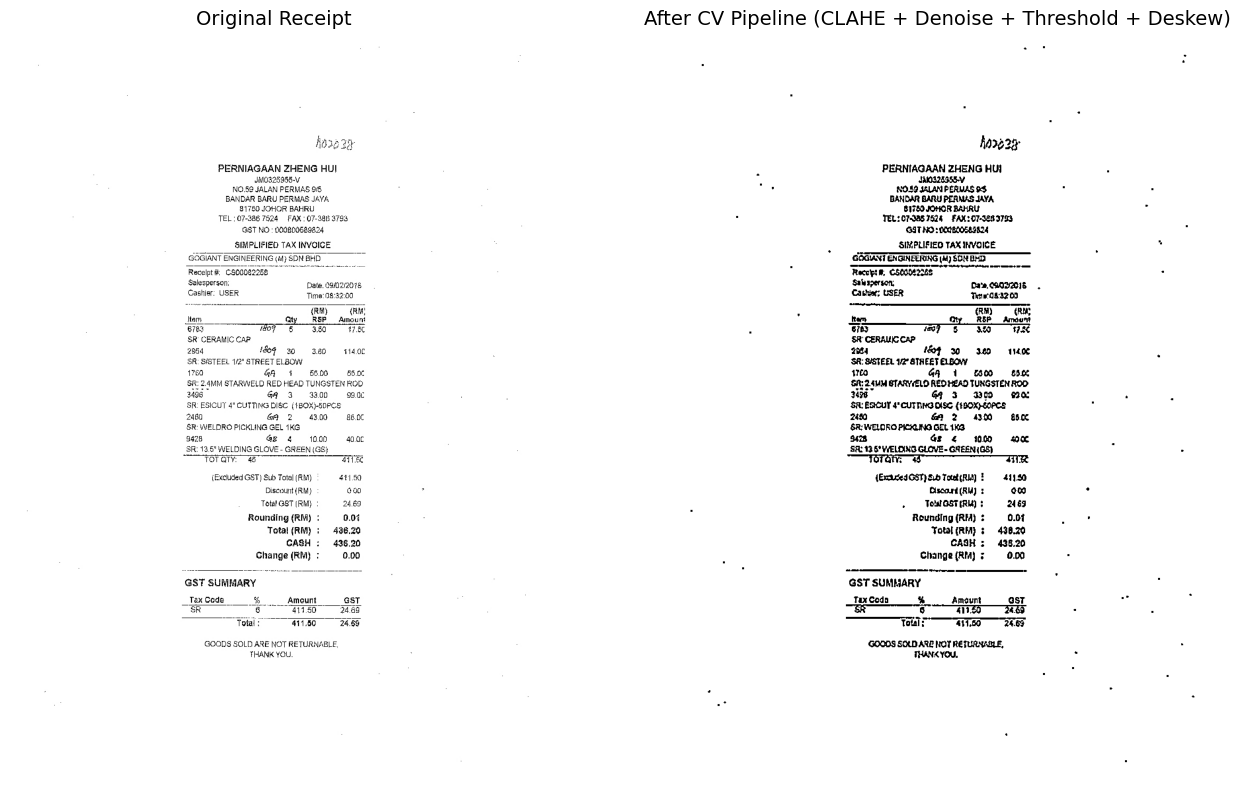

In [ ]:
for img_path in rec_paths[:3]:
    original = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    preprocessed = preprocess_receipt(img_path)

    fig, axes = plt.subplots(1, 2, figsize=(14, 8))
    axes[0].imshow(original)
    axes[0].set_title("Original Receipt", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(preprocessed, cmap='gray')
    axes[1].set_title("After CV Pipeline (CLAHE + Denoise + Threshold + Deskew)", fontsize=14)
    axes[1].axis('off')

    plt.tight_layout()
    fname = os.path.basename(img_path).replace('.jpg', '_comparison.png')
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=150)
    plt.show()

In [ ]:
import pandas as pd

df_results = pd.DataFrame(results)
df_results.head()


,file,merchant,date,time,currency,subtotal_orig,tax_orig,total_orig,subtotal_usd,tax_usd,total_usd,payment_method,items,ocr_text_preview
0,000.jpg,OJC MARKETING SDN BHD,2019-01-15,11:05:16,MYR,193.0,0.00,193.00,46.320,0.000,46.320,VISA,"[{""name"": ""KINGS SAFETY SHOES KWD 805"", ""qty"":...",tan chay yee\n*** COPY ***\nOJC MARKETING SDN ...
1,001.jpg,OJO MARKETING ISDN BHD,2019-01-02,14:47:14,MYR,150.0,20.00,170.00,36.000,4.800,40.800,VISA,"[{""name"": ""KINGS SAFETY SHOES"", ""qty"": 1, ""uni...",tan chay yee\nOJO MARKETING ISDN BHD\nŘÖCNo 53...
2,002.jpg,PERNIAGAAN ZHENG HUI,None,08:32:00,MYR,411.5,20.65,432.15,98.760,4.956,103.716,CASH,"[{""name"": ""SR CERAUX CAP"", ""qty"": 1, ""unit_pri...",•\n•\n•\n•\n.•\n•\n•\n•\nAnsoza\nPERNIAGAAN ZH...
3,003.jpg,Store,2018-02-01,16:43:17,MYR,NaN,NaN,NaN,NaN,NaN,NaN,None,[],001240360405\nTAX INVOICE\nTAX INVOICE NO: 197...
4,004.jpg,MFY,2018-01-19,17:09:21,MYR,38.9,NaN,51.00,9.336,NaN,12.240,CASH,"[{""name"": ""M. SpicyDeluxe"", ""qty"": 2, ""unit_pr...",MFY Side\nINVA\n2141900016842\nORD: #90/-REG #...
